# EDA 22: Promotion Active Calendar Analysis

This notebook analyzes the active promotion calendar, campaign overlap, promotion type, discount intensity, and revenue behavior during promotion versus non-promotion days.

Promotion-calendar features can be valid exogenous forecast features only when the future promotion calendar is known and allowed. If it is not known, use historical patterns, lagged promotion intensity, or separately forecast promotion activity.

## 1. Setup and file discovery

Locate the required `promotions.csv` file and optional revenue/order files recursively from the current working directory.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ROOT = Path.cwd()
REQUIRED_FILES = ["promotions.csv"]
OPTIONAL_FILES = ["orders.csv", "order_items.csv", "sales.csv"]
ALL_FILES = REQUIRED_FILES + OPTIONAL_FILES

def normalize_name(value):
    return re.sub(r"[^a-z0-9]+", "", str(value).strip().lower())

def display_warning(message):
    print(f"WARNING: {message}")

def find_csv_files(root, filenames):
    all_csvs = list(root.rglob("*.csv"))
    found = {}
    for filename in filenames:
        target = normalize_name(filename)
        matches = [p for p in all_csvs if normalize_name(p.name) == target]
        matches = sorted(matches, key=lambda p: (len(p.parts), str(p).lower()))
        found[filename] = matches[0] if matches else None
    return found

file_paths = find_csv_files(ROOT, ALL_FILES)
discovery_table = pd.DataFrame(
    {
        "file": list(file_paths.keys()),
        "path": [str(p) if p is not None else None for p in file_paths.values()],
        "required": [name in REQUIRED_FILES for name in file_paths.keys()],
        "status": ["found" if p is not None else "missing" for p in file_paths.values()],
    }
)
display(discovery_table)

if file_paths.get("promotions.csv") is None:
    display_warning("promotions.csv was not found. Promotion-calendar analysis will be skipped where necessary.")
for name in OPTIONAL_FILES:
    if file_paths.get(name) is None:
        print(f"Note: Optional file {name} was not found. Optional revenue/order analysis using it will be skipped.")

,file,path,required,status
0,promotions.csv,d:\Datathon-2026-Inlier\ai_eda\datathon-2026-r...,True,found
1,orders.csv,d:\Datathon-2026-Inlier\ai_eda\datathon-2026-r...,False,found
2,order_items.csv,d:\Datathon-2026-Inlier\ai_eda\datathon-2026-r...,False,found
3,sales.csv,d:\Datathon-2026-Inlier\ai_eda\datathon-2026-r...,False,found


## 2. Load promotions and optional revenue/order files

Load available CSVs safely with pandas and display basic schema information.

In [2]:
def safe_read_csv(path):
    if path is None:
        return None
    attempts = [
        {"low_memory": False},
        {"encoding": "utf-8-sig", "low_memory": False},
        {"encoding": "latin1", "low_memory": False},
    ]
    last_error = None
    for kwargs in attempts:
        try:
            return pd.read_csv(path, **kwargs)
        except Exception as exc:
            last_error = exc
    display_warning(f"Could not load {path}: {last_error}")
    return None

data = {name: safe_read_csv(path) for name, path in file_paths.items()}
promotions = data.get("promotions.csv")
orders = data.get("orders.csv")
order_items = data.get("order_items.csv")
sales = data.get("sales.csv")

load_summary = []
for name, df in data.items():
    load_summary.append(
        {
            "file": name,
            "loaded": df is not None,
            "rows": 0 if df is None else len(df),
            "columns": 0 if df is None else df.shape[1],
        }
    )
display(pd.DataFrame(load_summary))

for name, df in data.items():
    if df is not None:
        print(f"\n{name} columns:")
        print(list(df.columns))
        display(df.head())

,file,loaded,rows,columns
0,promotions.csv,True,50,10
1,orders.csv,True,646945,8
2,order_items.csv,True,714669,7
3,sales.csv,True,3833,3



promotions.csv columns:
['promo_id', 'promo_name', 'promo_type', 'discount_value', 'start_date', 'end_date', 'applicable_category', 'promo_channel', 'stackable_flag', 'min_order_value']


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0000,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0000,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0000,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0000,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0000,2013-07-30,2013-09-02,Streetwear,online,0,150000



orders.csv columns:
['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign



order_items.csv columns:
['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,"1,138.2200",0.0000,NaN,NaN
1,2,609,7,"10,166.2500",0.0000,NaN,NaN
2,3,396,3,"11,220.3300",0.0000,NaN,NaN
3,4,635,5,"10,639.2500",0.0000,NaN,NaN
4,6,1935,1,"1,597.8400",0.0000,NaN,NaN



sales.csv columns:
['Date', 'Revenue', 'COGS']


,Date,Revenue,COGS
0,2012-07-04,"5,123,547.9400","3,982,991.1900"
1,2012-07-05,"2,751,773.4500","2,150,580.2300"
2,2012-07-06,"3,054,029.4200","2,517,632.8400"
3,2012-07-07,"2,667,930.9400","2,108,246.6200"
4,2012-07-08,"2,360,851.9000","1,808,622.7900"


## 3. Identify promotion calendar, promotion type, discount, and revenue columns

Column detection handles case, spaces, underscores, and common synonyms. Revenue is read from `sales.csv` when possible, with order-item reconstruction as a fallback.

In [3]:
def score_column(col, include_terms=None, exclude_terms=None):
    n = normalize_name(col)
    score = 0
    include_terms = include_terms or []
    exclude_terms = exclude_terms or []
    for term, points in include_terms:
        if normalize_name(term) in n:
            score += points
    for term, points in exclude_terms:
        if normalize_name(term) in n:
            score -= points
    return score

def choose_column_by_terms(df, include_terms, exclude_terms=None, min_score=1):
    if df is None or df.empty:
        return None
    scored = [(score_column(col, include_terms, exclude_terms), col) for col in df.columns]
    scored = sorted(scored, key=lambda x: (x[0], -len(str(x[1]))), reverse=True)
    return scored[0][1] if scored and scored[0][0] >= min_score else None

def choose_numeric_column(df, include_terms, exclude_terms=None, min_score=1):
    if df is None or df.empty:
        return None
    scored = []
    for col in df.columns:
        numeric = pd.to_numeric(df[col], errors="coerce")
        valid_rate = numeric.notna().mean()
        if valid_rate < 0.5 or numeric.nunique(dropna=True) < 2:
            continue
        score = score_column(col, include_terms, exclude_terms) + valid_rate * 3
        scored.append((score, col))
    scored = sorted(scored, reverse=True)
    return scored[0][1] if scored and scored[0][0] >= min_score else None

def choose_date_column(df, preferred_terms=None):
    if df is None or df.empty:
        return None
    preferred_terms = preferred_terms or []
    candidates = []
    for col in df.columns:
        n = normalize_name(col)
        has_date_hint = any(term in n for term in ["date", "time", "start", "end"])
        if not has_date_hint:
            continue
        parsed = pd.to_datetime(df[col], errors="coerce")
        valid_rate = parsed.notna().mean()
        unique_count = parsed.nunique(dropna=True)
        name_score = score_column(
            col,
            preferred_terms + [("date", 10), ("time", 4), ("start", 8), ("end", 8), ("order", 5), ("sales", 5)],
            [("id", 8), ("zip", 8), ("price", 8), ("amount", 8), ("quantity", 8), ("qty", 8), ("value", 6)],
        )
        if valid_rate >= 0.45 and unique_count >= 1:
            candidates.append((valid_rate * 100 + name_score + min(unique_count, 100) * 0.01, col))
    candidates = sorted(candidates, reverse=True)
    return candidates[0][1] if candidates else None

def choose_common_key(left_df, right_df, left_terms, right_terms=None):
    if left_df is None or right_df is None:
        return None, None
    right_terms = right_terms or left_terms
    left_candidates = [
        col for col in left_df.columns
        if score_column(col, left_terms, [("date", 5), ("amount", 5), ("price", 5), ("quantity", 5), ("qty", 5)]) > 0
    ]
    right_candidates = [
        col for col in right_df.columns
        if score_column(col, right_terms, [("date", 5), ("amount", 5), ("price", 5), ("quantity", 5), ("qty", 5)]) > 0
    ]
    best = None
    for lcol in left_candidates:
        lvals = left_df[lcol].dropna().astype(str)
        if lvals.empty:
            continue
        lsample = set(lvals.head(10000))
        for rcol in right_candidates:
            rvals = right_df[rcol].dropna().astype(str)
            if rvals.empty:
                continue
            rsample = set(rvals.head(10000))
            overlap = len(lsample.intersection(rsample))
            score = overlap + score_column(lcol, left_terms) + score_column(rcol, right_terms)
            if best is None or score > best[0]:
                best = (score, lcol, rcol, overlap)
    if best is None or best[0] <= 0:
        return None, None
    return best[1], best[2]

promo_terms = [("promoid", 14), ("promotionid", 13), ("campaignid", 12), ("promo", 10), ("campaign", 9), ("promotion", 9), ("coupon", 7), ("offer", 5)]
order_terms = [("orderid", 14), ("order", 8), ("invoice", 6), ("transaction", 6), ("receipt", 4)]

promo_id_col = choose_column_by_terms(promotions, promo_terms, [("date", 6), ("amount", 6), ("value", 6)], min_score=6)
promo_name_col = choose_column_by_terms(promotions, [("promoname", 14), ("promotionname", 13), ("campaignname", 12), ("name", 6), ("title", 5)], [("id", 8), ("date", 8)], min_score=5)
promo_start_col = choose_date_column(promotions, [("startdate", 16), ("start", 12)])
promo_end_col = choose_date_column(promotions, [("enddate", 16), ("end", 12)])
promo_type_col = choose_column_by_terms(promotions, [("promotype", 14), ("promotiontype", 13), ("campaigntype", 12), ("discounttype", 11), ("type", 6)], [("id", 8), ("date", 8), ("value", 6), ("amount", 6)], min_score=5)
discount_value_col = choose_numeric_column(promotions, [("discountvalue", 14), ("discount", 10), ("value", 7), ("amount", 7)], [("id", 8), ("min", 4), ("order", 4)], min_score=5)

sales_date_col = choose_date_column(sales, [("date", 12), ("salesdate", 14)]) if sales is not None else None
sales_revenue_col = choose_numeric_column(
    sales,
    [("revenue", 14), ("sales", 10), ("amount", 8), ("total", 8), ("net", 6)],
    [("cost", 8), ("cogs", 8), ("id", 8), ("quantity", 8), ("qty", 8)],
    min_score=5,
) if sales is not None else None
order_id_col = choose_column_by_terms(orders, order_terms, [("date", 6), ("amount", 4), ("status", 3)], min_score=4) if orders is not None else None
order_date_col = choose_date_column(orders, [("orderdate", 16), ("order", 8)]) if orders is not None else None
item_order_col, order_order_col_for_items = choose_common_key(order_items, orders, order_terms) if order_items is not None and orders is not None else (None, None)
quantity_col = choose_numeric_column(order_items, [("quantity", 10), ("qty", 10), ("units", 6)], [("id", 10), ("price", 6), ("amount", 4)], min_score=5) if order_items is not None else None
price_col = choose_numeric_column(order_items, [("unitprice", 12), ("price", 10), ("sellingprice", 10), ("saleprice", 10)], [("id", 10), ("cost", 8), ("discount", 8), ("quantity", 8), ("qty", 8)], min_score=5) if order_items is not None else None
item_discount_col = choose_numeric_column(order_items, [("discountamount", 14), ("discount", 10)], [("id", 8), ("quantity", 8), ("qty", 8), ("price", 5)], min_score=5) if order_items is not None else None

detected = pd.DataFrame(
    [
        {"field": "promotions.promo_id", "column": promo_id_col},
        {"field": "promotions.promo_name", "column": promo_name_col},
        {"field": "promotions.start_date", "column": promo_start_col},
        {"field": "promotions.end_date", "column": promo_end_col},
        {"field": "promotions.promo_type", "column": promo_type_col},
        {"field": "promotions.discount_value", "column": discount_value_col},
        {"field": "sales.date", "column": sales_date_col},
        {"field": "sales.revenue", "column": sales_revenue_col},
        {"field": "orders.order_id", "column": order_id_col},
        {"field": "orders.order_date", "column": order_date_col},
        {"field": "order_items.order_id", "column": item_order_col},
        {"field": "order_items.quantity", "column": quantity_col},
        {"field": "order_items.price", "column": price_col},
        {"field": "order_items.discount", "column": item_discount_col},
    ]
)
display(detected)

required_ready = promotions is not None
if promotions is None:
    display_warning("promotions.csv is unavailable. Promotion-calendar sections will be skipped.")
if promo_start_col is None or promo_end_col is None:
    display_warning("Promotion start/end dates could not be identified. Active-calendar expansion will be skipped.")
if promo_type_col is None:
    print("Note: Promotion type was not identified. Type-specific analysis will use inferred labels where possible.")
if sales_revenue_col is None and not (orders is not None and order_items is not None and item_order_col is not None and order_date_col is not None and quantity_col is not None and price_col is not None):
    print("Note: Revenue could not be identified from optional files. Revenue comparison sections will be skipped.")

,field,column
0,promotions.promo_id,promo_id
1,promotions.promo_name,promo_name
2,promotions.start_date,start_date
3,promotions.end_date,end_date
4,promotions.promo_type,promo_type
5,promotions.discount_value,discount_value
6,sales.date,Date
7,sales.revenue,Revenue
8,orders.order_id,order_id
9,orders.order_date,order_date


## 4. Promotion data quality checks

Parse promotion dates, classify promotion type, and check missing dates, invalid periods, duplicate IDs, suspicious discounts, and extreme durations.

In [4]:
promo_clean = pd.DataFrame()
promotion_quality = {}
quality_warnings = []

def classify_promo_type(row):
    text = ""
    if promo_type_col is not None and promo_type_col in row.index:
        text += " " + str(row[promo_type_col]).lower()
    if promo_name_col is not None and promo_name_col in row.index:
        text += " " + str(row[promo_name_col]).lower()
    val = row.get("discount_value", np.nan)
    if any(token in text for token in ["percent", "percentage", "pct", "%"]):
        return "percentage"
    if any(token in text for token in ["fixed", "amount", "cash", "value", "vnd", "currency"]):
        return "fixed"
    if pd.notna(val):
        if 0 < val <= 1:
            return "percentage_inferred"
        if 1 < val <= 100 and any(token in text for token in ["sale", "discount", "promo"]):
            return "percentage_inferred"
        if val > 100:
            return "fixed_inferred"
    return "other_unknown"

if required_ready:
    promo_clean = promotions.copy()
    if promo_id_col is not None:
        promo_clean["promo_id_clean"] = promo_clean[promo_id_col].astype(str).str.strip()
    else:
        promo_clean["promo_id_clean"] = [f"promo_row_{i}" for i in range(len(promo_clean))]
    if promo_name_col is not None:
        promo_clean["promo_name_clean"] = promo_clean[promo_name_col].astype(str).str.strip()
    else:
        promo_clean["promo_name_clean"] = promo_clean["promo_id_clean"]
    promo_clean["promo_start"] = pd.to_datetime(promo_clean[promo_start_col], errors="coerce") if promo_start_col is not None else pd.NaT
    promo_clean["promo_end"] = pd.to_datetime(promo_clean[promo_end_col], errors="coerce") if promo_end_col is not None else pd.NaT
    promo_clean["discount_value"] = pd.to_numeric(promo_clean[discount_value_col], errors="coerce") if discount_value_col is not None else np.nan
    promo_clean["duration_days"] = (promo_clean["promo_end"] - promo_clean["promo_start"]).dt.days + 1
    promo_clean["invalid_date_range"] = promo_clean["promo_end"] < promo_clean["promo_start"]
    promo_clean["promo_type_class"] = promo_clean.apply(classify_promo_type, axis=1)
    promo_clean["promo_type_group"] = promo_clean["promo_type_class"].replace({"percentage_inferred": "percentage", "fixed_inferred": "fixed"})

    promotion_quality = {
        "number_of_promotions": len(promo_clean),
        "earliest_promotion_start_date": promo_clean["promo_start"].min(),
        "latest_promotion_end_date": promo_clean["promo_end"].max(),
        "missing_start_dates": int(promo_clean["promo_start"].isna().sum()),
        "missing_end_dates": int(promo_clean["promo_end"].isna().sum()),
        "invalid_promotion_periods": int(promo_clean["invalid_date_range"].sum()),
        "duplicate_promotion_ids": int(promo_clean["promo_id_clean"].duplicated().sum()),
        "negative_discount_values": int((promo_clean["discount_value"] < 0).sum()) if discount_value_col is not None else np.nan,
        "zero_discount_values": int((promo_clean["discount_value"] == 0).sum()) if discount_value_col is not None else np.nan,
        "percentage_discounts_above_100": int(((promo_clean["promo_type_group"] == "percentage") & (promo_clean["discount_value"] > 100)).sum()) if discount_value_col is not None else np.nan,
        "extreme_duration_over_180_days": int((promo_clean["duration_days"] > 180).sum()),
    }
    display(pd.DataFrame([promotion_quality]).T.rename(columns={0: "value"}))

    clean_summary_cols = ["promo_id_clean", "promo_name_clean", "promo_start", "promo_end", "duration_days", "promo_type_group", "promo_type_class", "discount_value"]
    display(promo_clean[clean_summary_cols].head(20))

    if promotion_quality["missing_start_dates"] or promotion_quality["missing_end_dates"]:
        quality_warnings.append("missing promotion start/end dates")
    if promotion_quality["invalid_promotion_periods"]:
        quality_warnings.append(f"{promotion_quality['invalid_promotion_periods']} invalid promotion date ranges")
    if promotion_quality["duplicate_promotion_ids"]:
        quality_warnings.append(f"{promotion_quality['duplicate_promotion_ids']} duplicate promotion IDs")
    if promotion_quality.get("percentage_discounts_above_100", 0):
        quality_warnings.append(f"{promotion_quality['percentage_discounts_above_100']} percentage discounts above 100")
    if promotion_quality.get("negative_discount_values", 0):
        quality_warnings.append(f"{promotion_quality['negative_discount_values']} negative discount values")
    if promotion_quality.get("extreme_duration_over_180_days", 0):
        quality_warnings.append(f"{promotion_quality['extreme_duration_over_180_days']} promotions longer than 180 days")
else:
    display_warning("Promotion quality checks skipped because promotions.csv is unavailable.")

,value
number_of_promotions,50
earliest_promotion_start_date,2013-01-31 00:00:00
latest_promotion_end_date,2022-12-31 00:00:00
missing_start_dates,0
missing_end_dates,0
invalid_promotion_periods,0
duplicate_promotion_ids,0
negative_discount_values,0
zero_discount_values,0
percentage_discounts_above_100,0


,promo_id_clean,promo_name_clean,promo_start,promo_end,duration_days,promo_type_group,promo_type_class,discount_value
0,PROMO-0001,Spring Sale 2013,2013-03-18,2013-04-17,31,percentage,percentage,12.0000
1,PROMO-0002,Mid-Year Sale 2013,2013-06-23,2013-07-22,30,percentage,percentage,18.0000
2,PROMO-0003,Fall Launch 2013,2013-08-30,2013-10-02,34,percentage,percentage,10.0000
3,PROMO-0004,Year-End Sale 2013,2013-11-18,2014-01-02,46,percentage,percentage,20.0000
4,PROMO-0005,Urban Blowout 2013,2013-07-30,2013-09-02,35,fixed,fixed,50.0000
5,PROMO-0006,Rural Special 2013,2013-01-31,2013-03-01,30,percentage,percentage,15.0000
6,PROMO-0007,Spring Sale 2014,2014-03-18,2014-04-17,31,percentage,percentage,12.0000
7,PROMO-0008,Mid-Year Sale 2014,2014-06-23,2014-07-22,30,percentage,percentage,18.0000
8,PROMO-0009,Fall Launch 2014,2014-08-30,2014-10-01,33,percentage,percentage,10.0000
9,PROMO-0010,Year-End Sale 2014,2014-11-19,2015-01-02,45,percentage,percentage,20.0000


## 5. Build active promotion calendar

Expand valid promotions into daily active dates and aggregate active counts, type counts, and discount intensity by calendar date.

In [5]:
promo_expanded = pd.DataFrame()
active_calendar = pd.DataFrame()
calendar_summary = {}

if not promo_clean.empty and promo_clean["promo_start"].notna().any() and promo_clean["promo_end"].notna().any():
    valid_promos = promo_clean.dropna(subset=["promo_start", "promo_end"]).copy()
    valid_promos = valid_promos.loc[~valid_promos["invalid_date_range"]].copy()
    expanded_rows = []
    for row in valid_promos.itertuples(index=False):
        date_range = pd.date_range(row.promo_start, row.promo_end, freq="D")
        for active_date in date_range:
            expanded_rows.append(
                {
                    "date": active_date,
                    "promo_id": row.promo_id_clean,
                    "promo_name": row.promo_name_clean,
                    "promo_type_group": row.promo_type_group,
                    "promo_type_class": row.promo_type_class,
                    "discount_value": row.discount_value,
                }
            )
    promo_expanded = pd.DataFrame(expanded_rows)
    if not promo_expanded.empty:
        active_calendar = promo_expanded.groupby("date").agg(
            has_active_promo=("promo_id", lambda s: True),
            active_promo_count=("promo_id", "nunique"),
            percentage_promo_count=("promo_type_group", lambda s: (s == "percentage").sum()),
            fixed_promo_count=("promo_type_group", lambda s: (s == "fixed").sum()),
            other_promo_count=("promo_type_group", lambda s: (~s.isin(["percentage", "fixed"])).sum()),
            avg_discount_value=("discount_value", "mean"),
            max_discount_value=("discount_value", "max"),
            min_discount_value=("discount_value", "min"),
            active_promo_ids=("promo_id", lambda s: ", ".join(sorted(set(s.astype(str)))[:20])),
            unique_active_promo_ids=("promo_id", "nunique"),
        ).sort_index()
        full_index = pd.date_range(active_calendar.index.min(), active_calendar.index.max(), freq="D")
        active_calendar = active_calendar.reindex(full_index)
        active_calendar.index.name = "date"
        active_calendar["has_active_promo"] = active_calendar["has_active_promo"].fillna(False).astype(bool)
        count_cols = ["active_promo_count", "percentage_promo_count", "fixed_promo_count", "other_promo_count", "unique_active_promo_ids"]
        active_calendar[count_cols] = active_calendar[count_cols].fillna(0).astype(int)
        active_calendar["active_promo_ids"] = active_calendar["active_promo_ids"].fillna("")
        calendar_summary = {
            "calendar_start": active_calendar.index.min().date(),
            "calendar_end": active_calendar.index.max().date(),
            "calendar_days": len(active_calendar),
            "dates_with_active_promotions": int(active_calendar["has_active_promo"].sum()),
            "max_simultaneous_active_promotions": int(active_calendar["active_promo_count"].max()),
            "average_active_promo_count_all_days": active_calendar["active_promo_count"].mean(),
            "average_active_promo_count_promo_days": active_calendar.loc[active_calendar["has_active_promo"], "active_promo_count"].mean(),
        }
        display(pd.DataFrame([calendar_summary]).T.rename(columns={0: "value"}))
        display(active_calendar.head(10).reset_index())
        display(active_calendar.tail(10).reset_index())
else:
    display_warning("Active promotion calendar skipped because promotion start/end dates are unavailable.")

,value
calendar_start,2013-01-31
calendar_end,2022-12-31
calendar_days,3622
dates_with_active_promotions,1707
max_simultaneous_active_promotions,2
average_active_promo_count_all_days,0.4768
average_active_promo_count_promo_days,1.0117


,date,has_active_promo,active_promo_count,percentage_promo_count,fixed_promo_count,other_promo_count,avg_discount_value,max_discount_value,min_discount_value,active_promo_ids,unique_active_promo_ids
0,2013-01-31,True,1,1,0,0,15.0000,15.0000,15.0000,PROMO-0006,1
1,2013-02-01,True,1,1,0,0,15.0000,15.0000,15.0000,PROMO-0006,1
2,2013-02-02,True,1,1,0,0,15.0000,15.0000,15.0000,PROMO-0006,1
3,2013-02-03,True,1,1,0,0,15.0000,15.0000,15.0000,PROMO-0006,1
4,2013-02-04,True,1,1,0,0,15.0000,15.0000,15.0000,PROMO-0006,1
5,2013-02-05,True,1,1,0,0,15.0000,15.0000,15.0000,PROMO-0006,1
6,2013-02-06,True,1,1,0,0,15.0000,15.0000,15.0000,PROMO-0006,1
7,2013-02-07,True,1,1,0,0,15.0000,15.0000,15.0000,PROMO-0006,1
8,2013-02-08,True,1,1,0,0,15.0000,15.0000,15.0000,PROMO-0006,1
9,2013-02-09,True,1,1,0,0,15.0000,15.0000,15.0000,PROMO-0006,1


,date,has_active_promo,active_promo_count,percentage_promo_count,fixed_promo_count,other_promo_count,avg_discount_value,max_discount_value,min_discount_value,active_promo_ids,unique_active_promo_ids
0,2022-12-22,True,1,1,0,0,20.0000,20.0000,20.0000,PROMO-0050,1
1,2022-12-23,True,1,1,0,0,20.0000,20.0000,20.0000,PROMO-0050,1
2,2022-12-24,True,1,1,0,0,20.0000,20.0000,20.0000,PROMO-0050,1
3,2022-12-25,True,1,1,0,0,20.0000,20.0000,20.0000,PROMO-0050,1
4,2022-12-26,True,1,1,0,0,20.0000,20.0000,20.0000,PROMO-0050,1
5,2022-12-27,True,1,1,0,0,20.0000,20.0000,20.0000,PROMO-0050,1
6,2022-12-28,True,1,1,0,0,20.0000,20.0000,20.0000,PROMO-0050,1
7,2022-12-29,True,1,1,0,0,20.0000,20.0000,20.0000,PROMO-0050,1
8,2022-12-30,True,1,1,0,0,20.0000,20.0000,20.0000,PROMO-0050,1
9,2022-12-31,True,1,1,0,0,20.0000,20.0000,20.0000,PROMO-0050,1


## 6. Active promotion count over time

Plot active promotion count and identify dates with the highest overlap of simultaneous campaigns.

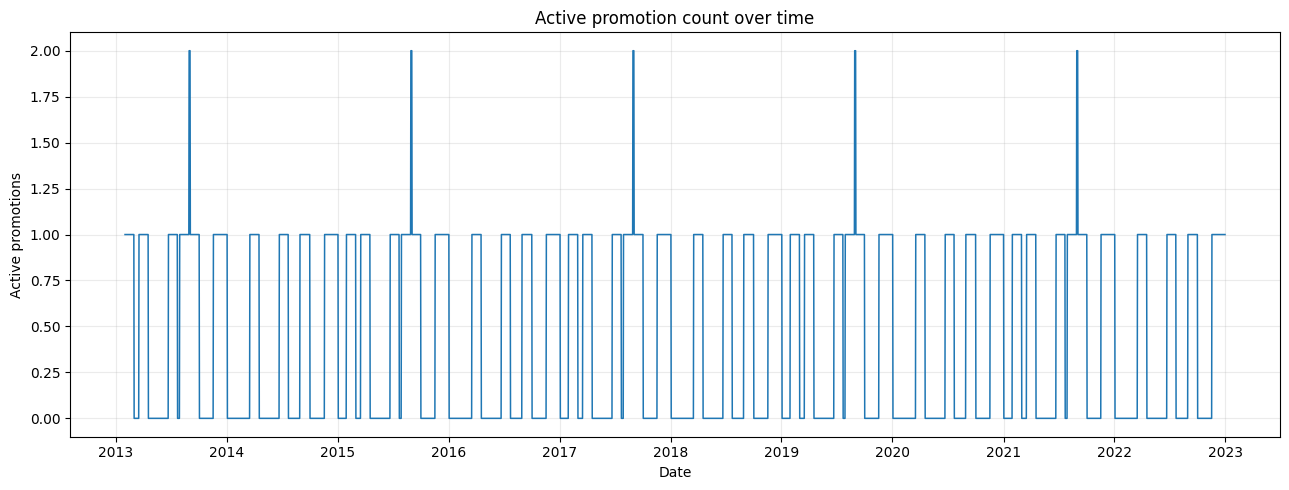

,date,active_promo_count,percentage_promo_count,fixed_promo_count,other_promo_count,avg_discount_value,max_discount_value,active_promo_ids
0,2013-08-30,2,1,1,0,30.0000,50.0000,"PROMO-0003, PROMO-0005"
1,2013-08-31,2,1,1,0,30.0000,50.0000,"PROMO-0003, PROMO-0005"
2,2013-09-01,2,1,1,0,30.0000,50.0000,"PROMO-0003, PROMO-0005"
3,2013-09-02,2,1,1,0,30.0000,50.0000,"PROMO-0003, PROMO-0005"
4,2015-08-30,2,1,1,0,30.0000,50.0000,"PROMO-0013, PROMO-0015"
5,2015-08-31,2,1,1,0,30.0000,50.0000,"PROMO-0013, PROMO-0015"
6,2015-09-01,2,1,1,0,30.0000,50.0000,"PROMO-0013, PROMO-0015"
7,2015-09-02,2,1,1,0,30.0000,50.0000,"PROMO-0013, PROMO-0015"
8,2017-08-30,2,1,1,0,30.0000,50.0000,"PROMO-0023, PROMO-0025"
9,2017-08-31,2,1,1,0,30.0000,50.0000,"PROMO-0023, PROMO-0025"


multiple active promotions occur on 0.6% of calendar days; 4+ simultaneous promotions occur on 0.0% of calendar days


In [6]:
top_overlap_dates = pd.DataFrame()
overlap_common_statement = "not available"

if not active_calendar.empty:
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(active_calendar.index, active_calendar["active_promo_count"], linewidth=1.1)
    ax.set_title("Active promotion count over time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Active promotions")
    plt.tight_layout()
    plt.show()

    top_overlap_dates = active_calendar.sort_values(["active_promo_count", "avg_discount_value"], ascending=False).head(25).reset_index()
    display(top_overlap_dates[["date", "active_promo_count", "percentage_promo_count", "fixed_promo_count", "other_promo_count", "avg_discount_value", "max_discount_value", "active_promo_ids"]])

    share_multi = (active_calendar["active_promo_count"] >= 2).mean()
    share_four_plus = (active_calendar["active_promo_count"] >= 4).mean()
    overlap_common_statement = f"multiple active promotions occur on {share_multi:.1%} of calendar days; 4+ simultaneous promotions occur on {share_four_plus:.1%} of calendar days"
    print(overlap_common_statement)
else:
    display_warning("Active promotion count plot skipped because active calendar is unavailable.")

## 7. Calendar heatmap of active promotions

Use a year × month heatmap-style matrix to show average active promotion count and promo-active days by month.

Average active promotion count by year and month:


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2013,1.0000,1.0000,0.4839,0.5667,0.0000,0.2667,0.7742,1.0645,1.0667,0.0645,0.4333,1.0000
2014,0.0645,0.0000,0.4516,0.5667,0.0000,0.2667,0.7097,0.0645,1.0000,0.0323,0.4000,1.0000
2015,0.1290,1.0000,0.4839,0.5667,0.0000,0.2667,0.7742,1.0645,1.0667,0.0323,0.4333,1.0000
2016,0.0645,0.0000,0.4516,0.5667,0.0000,0.2667,0.7097,0.0645,1.0000,0.0323,0.4333,1.0000
2017,0.1290,1.0000,0.4839,0.5667,0.0000,0.2667,0.7742,1.0645,1.0667,0.0645,0.4333,1.0000
2018,0.0645,0.0000,0.4516,0.5667,0.0000,0.2667,0.7097,0.0645,1.0000,0.0323,0.4333,1.0000
2019,0.1290,1.0000,0.4839,0.5667,0.0000,0.2667,0.7742,1.0645,1.0667,0.0323,0.4333,1.0000
2020,0.0645,0.0000,0.4516,0.5667,0.0000,0.2667,0.7097,0.0645,1.0000,0.0323,0.4333,1.0000
2021,0.0968,1.0000,0.4839,0.5667,0.0000,0.2667,0.7742,1.0645,1.0667,0.0645,0.4333,1.0000


Promo-active days by year and month:


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2013,1,28,15,17,0,8,24,31,30,2,13,31
2014,2,0,14,17,0,8,22,2,30,1,12,31
2015,4,28,15,17,0,8,24,31,30,1,13,31
2016,2,0,14,17,0,8,22,2,30,1,13,31
2017,4,28,15,17,0,8,24,31,30,2,13,31
2018,2,0,14,17,0,8,22,2,30,1,13,31
2019,4,28,15,17,0,8,24,31,30,1,13,31
2020,2,0,14,17,0,8,22,2,30,1,13,31
2021,3,28,15,17,0,8,24,31,30,2,13,31


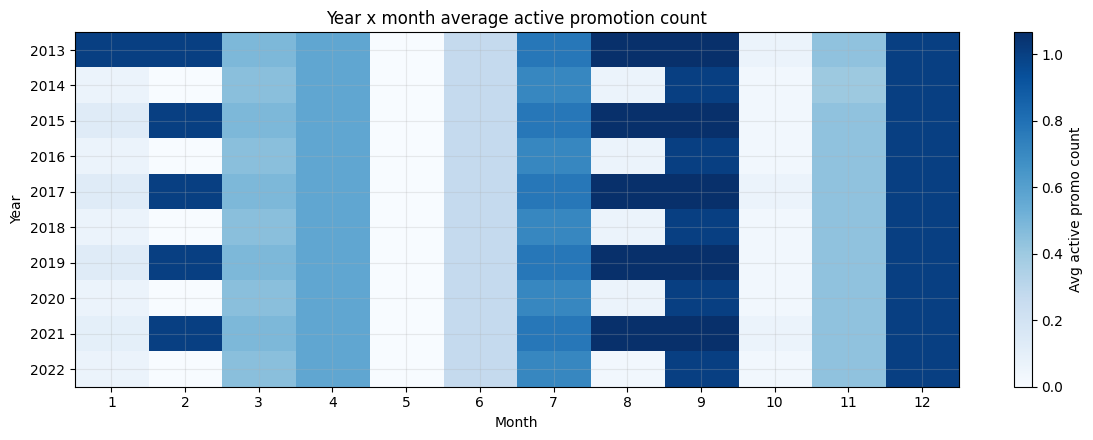

In [7]:
year_month_matrix = pd.DataFrame()
promo_active_days_matrix = pd.DataFrame()

if not active_calendar.empty:
    calendar_month = active_calendar.reset_index().copy()
    calendar_month["year"] = calendar_month["date"].dt.year
    calendar_month["month"] = calendar_month["date"].dt.month
    ym_summary = calendar_month.groupby(["year", "month"]).agg(
        avg_active_promo_count=("active_promo_count", "mean"),
        promo_active_days=("has_active_promo", "sum"),
        days=("has_active_promo", "size"),
    ).reset_index()
    ym_summary["promo_active_day_rate"] = ym_summary["promo_active_days"] / ym_summary["days"]
    year_month_matrix = ym_summary.pivot(index="year", columns="month", values="avg_active_promo_count")
    promo_active_days_matrix = ym_summary.pivot(index="year", columns="month", values="promo_active_days")
    print("Average active promotion count by year and month:")
    display(year_month_matrix)
    print("Promo-active days by year and month:")
    display(promo_active_days_matrix)

    fig, ax = plt.subplots(figsize=(12, max(4, len(year_month_matrix) * 0.45)))
    image = ax.imshow(year_month_matrix.values, aspect="auto", interpolation="nearest", cmap="Blues")
    ax.set_title("Year x month average active promotion count")
    ax.set_xlabel("Month")
    ax.set_ylabel("Year")
    ax.set_xticks(np.arange(len(year_month_matrix.columns)))
    ax.set_xticklabels([str(c) for c in year_month_matrix.columns])
    ax.set_yticks(np.arange(len(year_month_matrix.index)))
    ax.set_yticklabels([str(i) for i in year_month_matrix.index])
    fig.colorbar(image, ax=ax, label="Avg active promo count")
    plt.tight_layout()
    plt.show()
else:
    display_warning("Calendar heatmap skipped because active calendar is unavailable.")

## 8. Promotion type analysis

Compare promotion counts, duration, discount value, and active days by promotion type. Type labels may be inferred from text and discount values where explicit type is unclear.

,promo_type_group,promotions,avg_duration_days,median_duration_days,avg_discount_value,median_discount_value,active_promo_days
0,fixed,5,35.0000,35.0000,50.0000,50.0000,175
1,percentage,45,34.4889,31.0000,15.0000,15.0000,1552


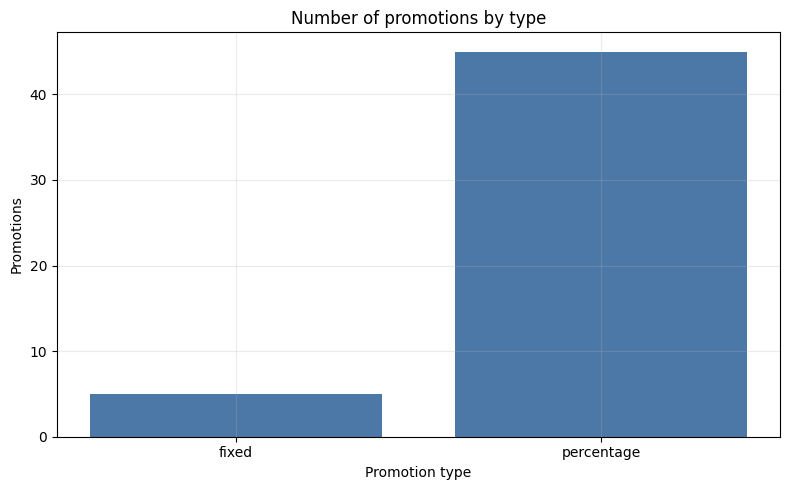

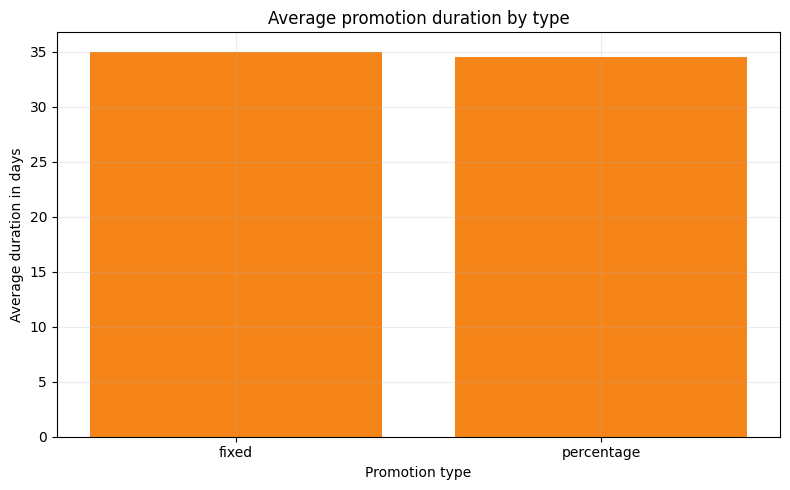

percentage promotions are 90.0% of promotions and fixed promotions are 10.0%


In [8]:
promo_type_summary = pd.DataFrame()
promo_type_daily = pd.DataFrame()
percentage_fixed_mix_statement = "not available"

if not promo_clean.empty:
    promo_type_summary = promo_clean.groupby("promo_type_group").agg(
        promotions=("promo_id_clean", "nunique"),
        avg_duration_days=("duration_days", "mean"),
        median_duration_days=("duration_days", "median"),
        avg_discount_value=("discount_value", "mean"),
        median_discount_value=("discount_value", "median"),
    ).reset_index()
    if not promo_expanded.empty:
        active_days_by_type = promo_expanded.groupby("promo_type_group").agg(active_promo_days=("date", "size")).reset_index()
        promo_type_summary = promo_type_summary.merge(active_days_by_type, on="promo_type_group", how="left")
    display(promo_type_summary)

    total_promos = promo_type_summary["promotions"].sum()
    pct_promos = promo_type_summary.loc[promo_type_summary["promo_type_group"] == "percentage", "promotions"].sum()
    fixed_promos = promo_type_summary.loc[promo_type_summary["promo_type_group"] == "fixed", "promotions"].sum()
    percentage_fixed_mix_statement = f"percentage promotions are {pct_promos / total_promos:.1%} of promotions and fixed promotions are {fixed_promos / total_promos:.1%}" if total_promos else "promotion type mix unavailable"

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(promo_type_summary["promo_type_group"].astype(str), promo_type_summary["promotions"], color="#4C78A8")
    ax.set_title("Number of promotions by type")
    ax.set_xlabel("Promotion type")
    ax.set_ylabel("Promotions")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(promo_type_summary["promo_type_group"].astype(str), promo_type_summary["avg_duration_days"], color="#F58518")
    ax.set_title("Average promotion duration by type")
    ax.set_xlabel("Promotion type")
    ax.set_ylabel("Average duration in days")
    plt.tight_layout()
    plt.show()

    print(percentage_fixed_mix_statement)
else:
    display_warning("Promotion type analysis skipped because promotion data is unavailable.")

## 9. Revenue during promo vs non-promo days

Build or load a daily revenue series and join it to the promotion calendar. This comparison is observational and may be confounded by seasonality, traffic, product mix, or campaign planning.

,label,days,total_revenue,avg_daily_revenue,median_daily_revenue,avg_order_count,avg_AOV
0,non-promo days,2126,"9,618,199,408.4800","4,524,082.5063","3,819,856.3500",163.2253,"29,136.7684"
1,promo days,1707,"6,812,277,177.0500","3,990,789.2074","3,428,606.6400",175.7047,"23,786.5235"


,promo_type_day,days,total_revenue,avg_daily_revenue,median_daily_revenue,avg_order_count,avg_AOV
1,mixed percentage and fixed,20,"106,615,653.7400","5,330,782.6870","5,442,950.6850",308.8000,"18,586.7058"
2,no active promo,2126,"9,618,199,408.4800","4,524,082.5063","3,819,856.3500",163.2253,"29,136.7684"
3,percentage promo active,1532,"6,187,700,336.5700","4,038,968.8881","3,504,258.9700",172.3544,"24,464.1934"
0,fixed promo active,155,"517,961,186.7400","3,341,685.0757","2,658,117.3400",191.6452,"17,759.4659"


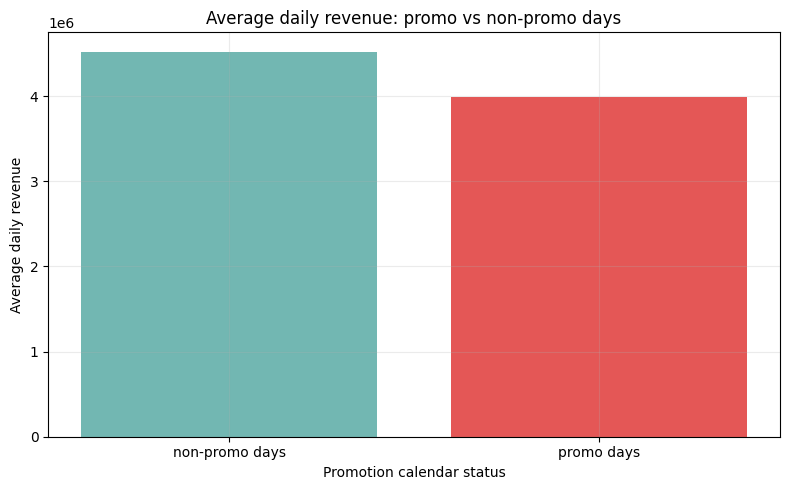

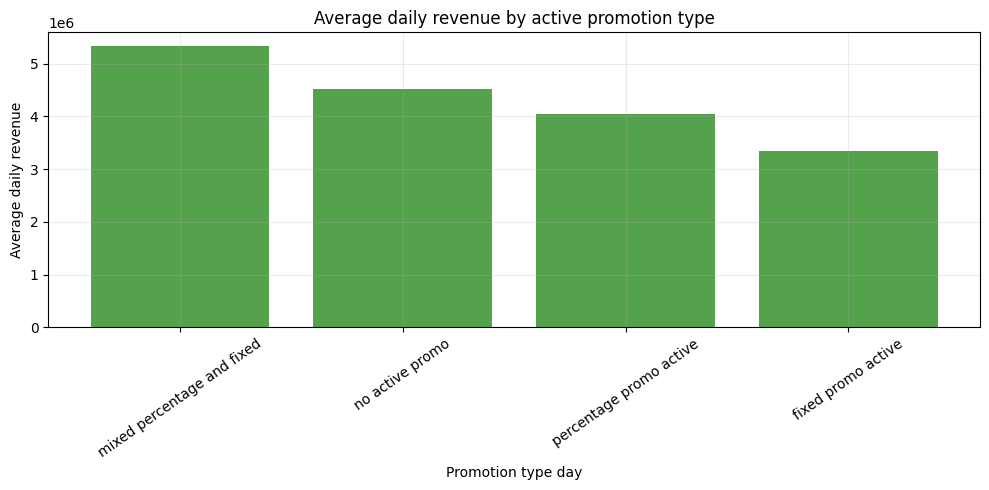

Revenue source used: sales.csv


In [9]:
daily_revenue = pd.DataFrame()
promo_revenue_comparison = pd.DataFrame()
promo_type_revenue_comparison = pd.DataFrame()
revenue_available = False
revenue_source = "not available"

if sales is not None and sales_date_col is not None and sales_revenue_col is not None:
    sales_work = sales.copy()
    sales_work["date"] = pd.to_datetime(sales_work[sales_date_col], errors="coerce").dt.floor("D")
    sales_work["revenue"] = pd.to_numeric(sales_work[sales_revenue_col], errors="coerce")
    daily_revenue = sales_work.dropna(subset=["date"]).groupby("date", as_index=False).agg(revenue=("revenue", "sum"))
    revenue_source = "sales.csv"
    revenue_available = True
elif orders is not None and order_items is not None and item_order_col is not None and order_order_col_for_items is not None and order_date_col is not None and quantity_col is not None and price_col is not None:
    orders_work = orders[[order_order_col_for_items, order_date_col]].copy()
    orders_work["_order_id"] = orders_work[order_order_col_for_items].astype(str)
    orders_work["date"] = pd.to_datetime(orders_work[order_date_col], errors="coerce").dt.floor("D")
    items_work = order_items.copy()
    items_work["_order_id"] = items_work[item_order_col].astype(str)
    qty = pd.to_numeric(items_work[quantity_col], errors="coerce")
    price = pd.to_numeric(items_work[price_col], errors="coerce")
    discount = pd.to_numeric(items_work[item_discount_col], errors="coerce").fillna(0) if item_discount_col is not None else 0
    items_work["item_revenue"] = qty * price
    item_orders = items_work.merge(orders_work[["_order_id", "date"]], on="_order_id", how="left")
    daily_revenue = item_orders.dropna(subset=["date"]).groupby("date", as_index=False).agg(revenue=("item_revenue", "sum"), order_count=("_order_id", "nunique"))
    revenue_source = "orders + order_items"
    revenue_available = True

if revenue_available:
    if "order_count" not in daily_revenue.columns and orders is not None and order_id_col is not None and order_date_col is not None:
        orders_counts = orders.copy()
        orders_counts["date"] = pd.to_datetime(orders_counts[order_date_col], errors="coerce").dt.floor("D")
        orders_counts["_order_id"] = orders_counts[order_id_col].astype(str)
        daily_counts = orders_counts.dropna(subset=["date"]).groupby("date", as_index=False).agg(order_count=("_order_id", "nunique"))
        daily_revenue = daily_revenue.merge(daily_counts, on="date", how="left")
    daily_revenue["order_count"] = daily_revenue["order_count"].fillna(np.nan)

    revenue_calendar = daily_revenue.copy()
    if not active_calendar.empty:
        cal = active_calendar.reset_index()
        revenue_calendar = revenue_calendar.merge(cal, on="date", how="left")
        count_cols = ["active_promo_count", "percentage_promo_count", "fixed_promo_count", "other_promo_count", "unique_active_promo_ids"]
        for col in count_cols:
            revenue_calendar[col] = revenue_calendar[col].fillna(0).astype(int)
        revenue_calendar["has_active_promo"] = revenue_calendar["has_active_promo"].fillna(False).astype(bool)
        for col in ["avg_discount_value", "max_discount_value", "min_discount_value"]:
            revenue_calendar[col] = revenue_calendar[col].fillna(0)
    else:
        revenue_calendar["has_active_promo"] = False
        revenue_calendar["active_promo_count"] = 0
        revenue_calendar["percentage_promo_count"] = 0
        revenue_calendar["fixed_promo_count"] = 0
        revenue_calendar["other_promo_count"] = 0

    revenue_calendar["AOV"] = revenue_calendar["revenue"] / revenue_calendar["order_count"].replace(0, np.nan)
    promo_revenue_comparison = revenue_calendar.groupby("has_active_promo").agg(
        days=("date", "size"),
        total_revenue=("revenue", "sum"),
        avg_daily_revenue=("revenue", "mean"),
        median_daily_revenue=("revenue", "median"),
        avg_order_count=("order_count", "mean"),
        avg_AOV=("AOV", "mean"),
    ).reset_index()
    promo_revenue_comparison["label"] = np.where(promo_revenue_comparison["has_active_promo"], "promo days", "non-promo days")
    display(promo_revenue_comparison[["label", "days", "total_revenue", "avg_daily_revenue", "median_daily_revenue", "avg_order_count", "avg_AOV"]])

    revenue_calendar["promo_type_day"] = np.select(
        [
            (revenue_calendar["percentage_promo_count"] > 0) & (revenue_calendar["fixed_promo_count"] > 0),
            revenue_calendar["percentage_promo_count"] > 0,
            revenue_calendar["fixed_promo_count"] > 0,
            revenue_calendar["other_promo_count"] > 0,
        ],
        ["mixed percentage and fixed", "percentage promo active", "fixed promo active", "other/unknown promo active"],
        default="no active promo",
    )
    promo_type_revenue_comparison = revenue_calendar.groupby("promo_type_day").agg(
        days=("date", "size"),
        total_revenue=("revenue", "sum"),
        avg_daily_revenue=("revenue", "mean"),
        median_daily_revenue=("revenue", "median"),
        avg_order_count=("order_count", "mean"),
        avg_AOV=("AOV", "mean"),
    ).reset_index().sort_values("avg_daily_revenue", ascending=False)
    display(promo_type_revenue_comparison)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(promo_revenue_comparison["label"], promo_revenue_comparison["avg_daily_revenue"], color=["#72B7B2", "#E45756"])
    ax.set_title("Average daily revenue: promo vs non-promo days")
    ax.set_xlabel("Promotion calendar status")
    ax.set_ylabel("Average daily revenue")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(promo_type_revenue_comparison["promo_type_day"], promo_type_revenue_comparison["avg_daily_revenue"], color="#54A24B")
    ax.set_title("Average daily revenue by active promotion type")
    ax.set_xlabel("Promotion type day")
    ax.set_ylabel("Average daily revenue")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.show()

    print(f"Revenue source used: {revenue_source}")
else:
    print("Revenue comparison skipped because revenue could not be identified from optional files.")

## 10. Promotion overlap and intensity analysis

Group days by the number of simultaneous active promotions and compare revenue metrics when revenue data is available.

,active_promo_bin,days,total_revenue,avg_daily_revenue,median_daily_revenue,avg_order_count,avg_AOV,avg_discount_value
0,0 active promos,2126,"9,618,199,408.4800","4,524,082.5063","3,819,856.3500",163.2253,"29,136.7684",0.0000
1,1 active promo,1687,"6,705,661,523.3100","3,974,903.0962","3,391,644.1300",174.1269,"23,848.1692",18.6248
2,2-3 active promos,20,"106,615,653.7400","5,330,782.6870","5,442,950.6850",308.8000,"18,586.7058",30.0000
3,4+ active promos,0,0.0000,NaN,NaN,NaN,NaN,NaN


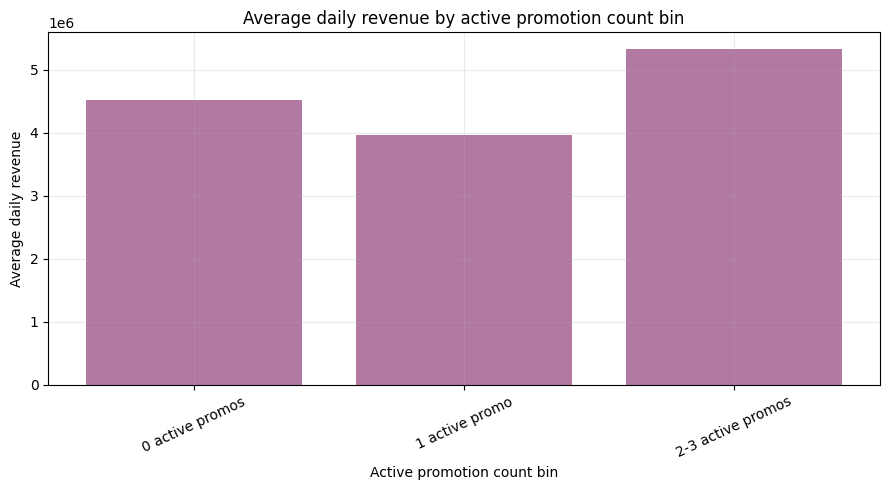

highest average daily revenue appears in 2-3 active promos (5,330,782.69)


In [10]:
overlap_revenue = pd.DataFrame()
overlap_revenue_statement = "not available"

if revenue_available and "revenue_calendar" in globals():
    revenue_calendar["active_promo_bin"] = pd.cut(
        revenue_calendar["active_promo_count"],
        bins=[-0.1, 0, 1, 3, np.inf],
        labels=["0 active promos", "1 active promo", "2-3 active promos", "4+ active promos"],
    )
    overlap_revenue = revenue_calendar.groupby("active_promo_bin", observed=False).agg(
        days=("date", "size"),
        total_revenue=("revenue", "sum"),
        avg_daily_revenue=("revenue", "mean"),
        median_daily_revenue=("revenue", "median"),
        avg_order_count=("order_count", "mean"),
        avg_AOV=("AOV", "mean"),
        avg_discount_value=("avg_discount_value", "mean"),
    ).reset_index()
    display(overlap_revenue)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(overlap_revenue["active_promo_bin"].astype(str), overlap_revenue["avg_daily_revenue"], color="#B279A2")
    ax.set_title("Average daily revenue by active promotion count bin")
    ax.set_xlabel("Active promotion count bin")
    ax.set_ylabel("Average daily revenue")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()

    if not overlap_revenue.empty:
        top_bin = overlap_revenue.sort_values("avg_daily_revenue", ascending=False).iloc[0]
        overlap_revenue_statement = f"highest average daily revenue appears in {top_bin['active_promo_bin']} ({top_bin['avg_daily_revenue']:,.2f})"
        print(overlap_revenue_statement)
else:
    print("Promotion overlap revenue comparison skipped because revenue data is unavailable.")

## 11. Historical promotion seasonality

Aggregate active promotion metrics by month of year, quarter, and year. These historical patterns are useful when future promotion plans are unknown.

,month_of_year,avg_active_promo_count,promo_active_days,days,avg_percentage_promo_count,avg_fixed_promo_count,avg_discount_value,promo_active_day_rate
0,1,0.0929,26,280,0.0929,0.0000,18.2692,0.0929
1,2,0.4965,140,282,0.4965,0.0000,15.0000,0.4965
2,3,0.4677,145,310,0.4677,0.0000,12.1034,0.4677
3,4,0.5667,170,300,0.5667,0.0000,12.0000,0.5667
4,5,0.0000,0,310,0.0000,0.0000,NaN,0.0000
5,6,0.2667,80,300,0.2667,0.0000,18.0000,0.2667
6,7,0.7419,230,310,0.7097,0.0323,19.3913,0.7419
7,8,0.5613,164,310,0.0613,0.5000,46.5854,0.5290
8,9,1.0333,300,300,1.0000,0.0333,10.6667,1.0000
9,10,0.0419,13,310,0.0419,0.0000,10.0000,0.0419


,quarter,avg_active_promo_count,promo_active_days,days,avg_discount_value,promo_active_day_rate
0,1,0.3567,311,872,13.9228,0.3567
1,2,0.2747,250,910,13.9200,0.2747
2,3,0.7761,694,920,22.0461,0.7543
3,4,0.4913,452,920,19.7124,0.4913


,year,avg_active_promo_count,promo_active_days,days,avg_discount_value,promo_active_day_rate
0,2013,0.6090,200,335,21.0600,0.5970
1,2014,0.3808,139,365,15.4101,0.3808
2,2015,0.5644,202,365,21.0743,0.5534
3,2016,0.3825,140,366,15.4429,0.3825
4,2017,0.5671,203,365,21.0197,0.5562
5,2018,0.3836,140,365,15.4429,0.3836
6,2019,0.5644,202,365,21.0743,0.5534
7,2020,0.3825,140,366,15.4429,0.3825
8,2021,0.5644,202,365,21.0248,0.5534
9,2022,0.3808,139,365,15.4820,0.3808


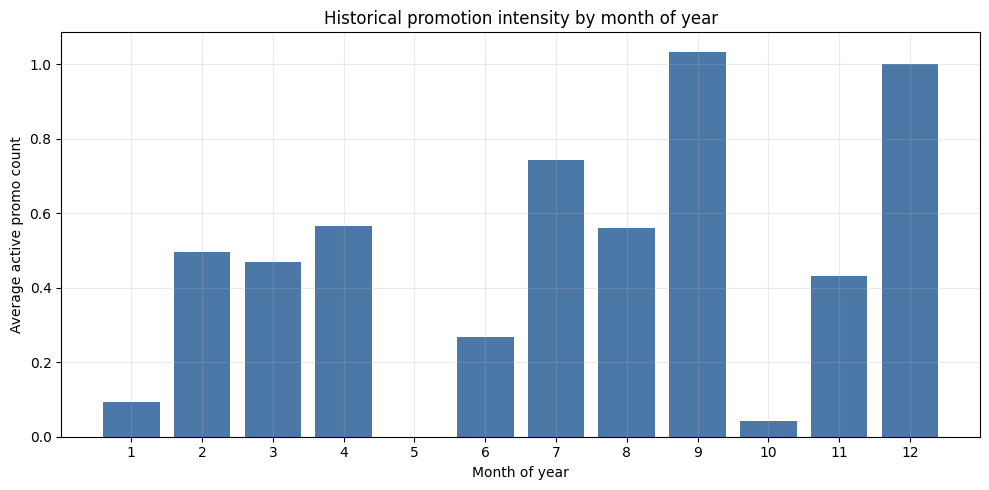

In [11]:
promo_month_seasonality = pd.DataFrame()
promo_quarter_seasonality = pd.DataFrame()
promo_year_seasonality = pd.DataFrame()

if not active_calendar.empty:
    season = active_calendar.reset_index().copy()
    season["month_of_year"] = season["date"].dt.month
    season["quarter"] = season["date"].dt.quarter
    season["year"] = season["date"].dt.year
    promo_month_seasonality = season.groupby("month_of_year").agg(
        avg_active_promo_count=("active_promo_count", "mean"),
        promo_active_days=("has_active_promo", "sum"),
        days=("has_active_promo", "size"),
        avg_percentage_promo_count=("percentage_promo_count", "mean"),
        avg_fixed_promo_count=("fixed_promo_count", "mean"),
        avg_discount_value=("avg_discount_value", "mean"),
    ).reset_index()
    promo_month_seasonality["promo_active_day_rate"] = promo_month_seasonality["promo_active_days"] / promo_month_seasonality["days"]
    promo_quarter_seasonality = season.groupby("quarter").agg(
        avg_active_promo_count=("active_promo_count", "mean"),
        promo_active_days=("has_active_promo", "sum"),
        days=("has_active_promo", "size"),
        avg_discount_value=("avg_discount_value", "mean"),
    ).reset_index()
    promo_quarter_seasonality["promo_active_day_rate"] = promo_quarter_seasonality["promo_active_days"] / promo_quarter_seasonality["days"]
    promo_year_seasonality = season.groupby("year").agg(
        avg_active_promo_count=("active_promo_count", "mean"),
        promo_active_days=("has_active_promo", "sum"),
        days=("has_active_promo", "size"),
        avg_discount_value=("avg_discount_value", "mean"),
    ).reset_index()
    promo_year_seasonality["promo_active_day_rate"] = promo_year_seasonality["promo_active_days"] / promo_year_seasonality["days"]
    display(promo_month_seasonality)
    display(promo_quarter_seasonality)
    display(promo_year_seasonality)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(promo_month_seasonality["month_of_year"].astype(str), promo_month_seasonality["avg_active_promo_count"], color="#4C78A8")
    ax.set_title("Historical promotion intensity by month of year")
    ax.set_xlabel("Month of year")
    ax.set_ylabel("Average active promo count")
    plt.tight_layout()
    plt.show()
else:
    display_warning("Historical promotion seasonality skipped because active calendar is unavailable.")

## 12. Forecast feature preview

Daily promotion-calendar features are valid for a forecast/test period only when that future calendar is known and allowed. Otherwise use historical pattern features or lagged promotion activity only.

In [12]:
forecast_features = pd.DataFrame()

if not active_calendar.empty:
    feat = active_calendar.reset_index().copy()
    feat["month"] = feat["date"].dt.to_period("M").dt.to_timestamp()
    feat["month_of_year"] = feat["date"].dt.month
    month_active_days = feat.groupby("month")["has_active_promo"].sum().rename("promo_active_days_in_month")
    feat = feat.merge(month_active_days, on="month", how="left")

    historical = feat[["date", "month_of_year", "active_promo_count", "has_active_promo"]].copy()
    historical["historical_avg_active_promo_count_by_month"] = historical.groupby("month_of_year")["active_promo_count"].transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
    historical["historical_promo_active_day_rate_by_month"] = historical.groupby("month_of_year")["has_active_promo"].transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
    feat = feat.merge(historical[["date", "historical_avg_active_promo_count_by_month", "historical_promo_active_day_rate_by_month"]], on="date", how="left")

    forecast_features = feat[
        [
            "date",
            "has_active_promo",
            "active_promo_count",
            "percentage_promo_count",
            "fixed_promo_count",
            "other_promo_count",
            "avg_discount_value",
            "max_discount_value",
            "promo_active_days_in_month",
            "historical_avg_active_promo_count_by_month",
            "historical_promo_active_day_rate_by_month",
        ]
    ].copy()
    print("Forecast feature preview. Calendar features are valid for future periods only if the future promotion calendar is known and allowed.")
    display(forecast_features.head(40))
else:
    display_warning("Forecast feature preview skipped because active calendar is unavailable.")

Forecast feature preview. Calendar features are valid for future periods only if the future promotion calendar is known and allowed.


,date,has_active_promo,active_promo_count,percentage_promo_count,fixed_promo_count,other_promo_count,avg_discount_value,max_discount_value,promo_active_days_in_month,historical_avg_active_promo_count_by_month,historical_promo_active_day_rate_by_month
0,2013-01-31,True,1,1,0,0,15.0000,15.0000,1,NaN,NaN
1,2013-02-01,True,1,1,0,0,15.0000,15.0000,28,NaN,NaN
2,2013-02-02,True,1,1,0,0,15.0000,15.0000,28,1.0000,1.0000
3,2013-02-03,True,1,1,0,0,15.0000,15.0000,28,1.0000,1.0000
4,2013-02-04,True,1,1,0,0,15.0000,15.0000,28,1.0000,1.0000
5,2013-02-05,True,1,1,0,0,15.0000,15.0000,28,1.0000,1.0000
6,2013-02-06,True,1,1,0,0,15.0000,15.0000,28,1.0000,1.0000
7,2013-02-07,True,1,1,0,0,15.0000,15.0000,28,1.0000,1.0000
8,2013-02-08,True,1,1,0,0,15.0000,15.0000,28,1.0000,1.0000
9,2013-02-09,True,1,1,0,0,15.0000,15.0000,28,1.0000,1.0000


## 13. Key observations and warnings

Final summary of promotion calendar coverage, overlap, type mix, revenue comparison, data quality, and feature recommendations.

In [13]:
print("Concise insight summary")
print("=" * 80)

if calendar_summary:
    print(f"Promotion calendar coverage period: {calendar_summary['calendar_start']} to {calendar_summary['calendar_end']}.")
    print(f"Dates with active promotions: {calendar_summary['dates_with_active_promotions']:,} of {calendar_summary['calendar_days']:,} calendar days.")
    print(f"Maximum simultaneous active promotions: {calendar_summary['max_simultaneous_active_promotions']:,}.")
else:
    print("Promotion calendar coverage period: not available.")

if not top_overlap_dates.empty:
    top_periods = "; ".join(
        f"{row['date'].date()} ({row['active_promo_count']} active promos, avg discount {row['avg_discount_value']:.2f})"
        for row in top_overlap_dates.head(5).to_dict("records")
    )
    print(f"Periods with highest promotion intensity: {top_periods}.")
    print(f"Promotion overlap frequency: {overlap_common_statement}.")
else:
    print("Periods with highest promotion intensity: not available.")

print(f"Percentage vs fixed promotion mix: {percentage_fixed_mix_statement}.")

if not promo_revenue_comparison.empty:
    promo_rows = {row["label"]: row for row in promo_revenue_comparison.to_dict("records")}
    if "promo days" in promo_rows and "non-promo days" in promo_rows:
        diff = promo_rows["promo days"]["avg_daily_revenue"] - promo_rows["non-promo days"]["avg_daily_revenue"]
        pct = diff / promo_rows["non-promo days"]["avg_daily_revenue"] if promo_rows["non-promo days"]["avg_daily_revenue"] else np.nan
        print(f"Revenue on promo vs non-promo days: promo days average {promo_rows['promo days']['avg_daily_revenue']:,.2f}, non-promo days average {promo_rows['non-promo days']['avg_daily_revenue']:,.2f}, difference {diff:,.2f} ({pct:.1%}).")
else:
    print("Revenue on promo vs non-promo days: not available.")

if not promo_type_revenue_comparison.empty:
    top_type = promo_type_revenue_comparison.sort_values("avg_daily_revenue", ascending=False).iloc[0]
    print(f"Revenue by promotion type: highest average daily revenue appears for {top_type['promo_type_day']} ({top_type['avg_daily_revenue']:,.2f}).")
else:
    print("Revenue by promotion type: not available.")

if not overlap_revenue.empty:
    print(f"Revenue by promotion overlap: {overlap_revenue_statement}.")

print("Promotion data quality warnings: " + ("; ".join(quality_warnings) if quality_warnings else "none material for detected fields") + ".")

recommended_features = [
    "has_active_promo",
    "active_promo_count",
    "percentage_promo_count",
    "fixed_promo_count",
    "other_promo_count",
    "avg_discount_value",
    "max_discount_value",
    "promo_active_days_in_month",
    "historical_avg_active_promo_count_by_month",
    "historical_promo_active_day_rate_by_month",
]
print("Recommended promotion-calendar forecast features: " + ", ".join(recommended_features) + ".")
print("Forecasting warning: promotion-calendar features can be used for the test period only if the future promotion calendar is known and allowed. Otherwise use historical patterns, lagged promotion intensity, or separately forecast promotion activity.")
print("Interpretation warning: revenue comparisons are observational and may be confounded by seasonality, traffic, product mix, or campaign planning.")

Concise insight summary
Promotion calendar coverage period: 2013-01-31 to 2022-12-31.
Dates with active promotions: 1,707 of 3,622 calendar days.
Maximum simultaneous active promotions: 2.
Periods with highest promotion intensity: 2013-08-30 (2 active promos, avg discount 30.00); 2013-08-31 (2 active promos, avg discount 30.00); 2013-09-01 (2 active promos, avg discount 30.00); 2013-09-02 (2 active promos, avg discount 30.00); 2015-08-30 (2 active promos, avg discount 30.00).
Promotion overlap frequency: multiple active promotions occur on 0.6% of calendar days; 4+ simultaneous promotions occur on 0.0% of calendar days.
Percentage vs fixed promotion mix: percentage promotions are 90.0% of promotions and fixed promotions are 10.0%.
Revenue on promo vs non-promo days: promo days average 3,990,789.21, non-promo days average 4,524,082.51, difference -533,293.30 (-11.8%).
Revenue by promotion type: highest average daily revenue appears for mixed percentage and fixed (5,330,782.69).
Revenue 